**Aulas 08 - Árvores de Decisão**

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/06_decision_trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/06_decision_trees.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

O projeto requer Python 3.7 ou acima:

In [1]:
import sys

assert sys.version_info >= (3, 7)

Também requer Scikit-Learn ≥ 1.0.1:

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Definindo as fontes dos gráficos, apenas para estética:

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Define a função `save_fig()`, que gravará as imagens geradas para os gráficos na pasta `images/decision_trees`. Assim todas as imagens plotadas abaixo, ficam disponíveis para download.

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "decision_trees"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Treinando e Visualizando uma Árvore de Decisão

In [5]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

**Graphivz** - É um software de visualização gráfica opensource, que nos ajudará a visualizar a árvore de decisão treinada.

In [6]:
from sklearn.tree import export_graphviz

export_graphviz(
        tree_clf,
        out_file=str(IMAGES_PATH / "iris_tree.dot"),
        feature_names=["petal length (cm)", "petal width (cm)"],
        class_names=iris.target_names,
        rounded=True,
        filled=True
    )

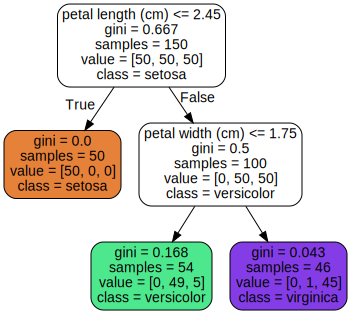

In [7]:
from graphviz import Source

Source.from_file(IMAGES_PATH / "iris_tree.dot")

O Graphviz também fornece a ferramenta de linha de comando `dot` para converter arquivos `.dot` em uma variedade de formatos. O comando a seguir converte o arquivo `.dot` em uma imagem `.png`:

In [8]:
!dot -Tpng {IMAGES_PATH / "iris_tree.dot"} -o {IMAGES_PATH / "iris_tree.png"}

## Entropia vs Impureza de Gini

Modelo de árvore de decisão utilizando **Entropia**.

Utilizando a propriedade `criterion` com o valor `entropy`!

In [9]:
tree_clf_entropy = DecisionTreeClassifier(max_depth=2, random_state=42, criterion="entropy")
tree_clf_entropy.fit(X_iris, y_iris)

DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=42)

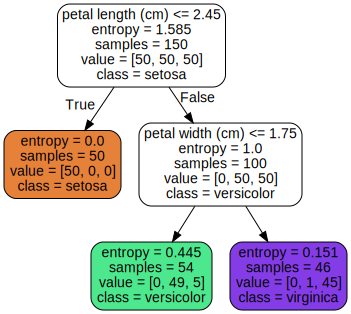

In [10]:
export_graphviz(
        tree_clf_entropy,
        out_file=str(IMAGES_PATH / "iris_tree_entropy.dot"),
        feature_names=["petal length (cm)", "petal width (cm)"],
        class_names=iris.target_names,
        rounded=True,
        filled=True
    )

Source.from_file(IMAGES_PATH / "iris_tree_entropy.dot")

In [11]:
!dot -Tpng {IMAGES_PATH / "iris_tree_entropy.dot"} -o {IMAGES_PATH / "iris_tree_entropy.png"}

## Fazendo Predições

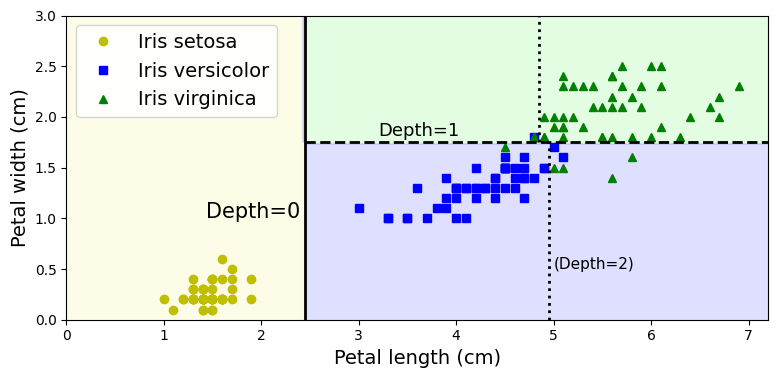

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Formatação dos detalhes
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])
plt.figure(figsize=(8, 4))

lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
y_pred = tree_clf.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

# Definição de formatações, labels e gravando a imagem
tree_clf_deeper = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf_deeper.fit(X_iris, y_iris)
th0, th1, th2a, th2b = tree_clf_deeper.tree_.threshold[[0, 2, 3, 6]]
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.plot([th0, th0], [0, 3], "k-", linewidth=2)
plt.plot([th0, 7.2], [th1, th1], "k--", linewidth=2)
plt.plot([th2a, th2a], [0, th1], "k:", linewidth=2)
plt.plot([th2b, th2b], [th1, 3], "k:", linewidth=2)
plt.text(th0 - 0.05, 1.0, "Depth=0", horizontalalignment="right", fontsize=15)
plt.text(3.2, th1 + 0.02, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.text(th2a + 0.05, 0.5, "(Depth=2)", fontsize=11)
plt.axis([0, 7.2, 0, 3])
plt.legend()
save_fig("decision_tree_decision_boundaries_plot")

plt.show()

Você pode acessar a estrutura da árvore através do atributo `tree_`:

In [13]:
tree_clf.tree_

Para mais informações, e saber como navegar nas informações do atributo, veja este comando para acessar a documentação da classe `Tree`:

In [17]:
help(sklearn.tree._tree.Tree)

Help on class Tree in module sklearn.tree._tree:

class Tree(builtins.object)
 |  Array-based representation of a binary decision tree.
 |
 |  The binary tree is represented as a number of parallel arrays. The i-th
 |  element of each array holds information about the node `i`. Node 0 is the
 |  tree's root. You can find a detailed description of all arrays in
 |  `_tree.pxd`. NOTE: Some of the arrays only apply to either leaves or split
 |  nodes, resp. In this case the values of nodes of the other type are
 |  arbitrary!
 |
 |  Attributes
 |  ----------
 |  node_count : intp_t
 |      The number of nodes (internal nodes + leaves) in the tree.
 |
 |  capacity : intp_t
 |      The current capacity (i.e., size) of the arrays, which is at least as
 |      great as `node_count`.
 |
 |  max_depth : intp_t
 |      The depth of the tree, i.e. the maximum depth of its leaves.
 |
 |  children_left : array of intp_t, shape [node_count]
 |      children_left[i] holds the node id of the left chil

## Estimando as Probabilidades de Classes

In [15]:
tree_clf.predict_proba([[5, 1.5]]).round(3)

array([[0.   , 0.907, 0.093]])

In [16]:
tree_clf.predict([[5, 1.5]])

array([1])

### FIM DA 1ª DA DEMONSTRAÇÃO - voltar aos slides

# Overfitting e Hiper Parâmetros de Regularização

In [18]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)

tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)
tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

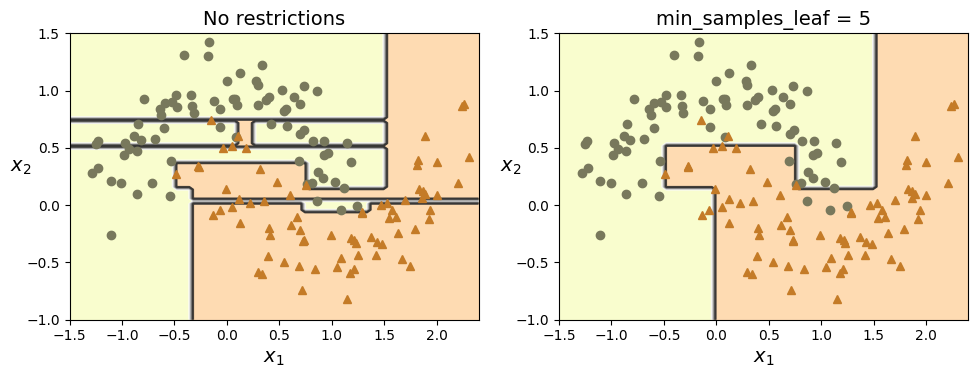

In [19]:
def plot_decision_boundary(clf, X, y, axes, cmap):
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=cmap)
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8)
    colors = {"Wistia": ["#78785c", "#c47b27"], "Pastel1": ["red", "blue"]}
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[cmap][idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4))
plt.sca(axes[0])
plot_decision_boundary(tree_clf1, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title("No restrictions")
plt.sca(axes[1])
plot_decision_boundary(tree_clf2, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title(f"min_samples_leaf = {tree_clf2.min_samples_leaf}")
#plt.ylabel("")
save_fig("min_samples_leaf_plot")
plt.show()

In [20]:
X_moons_test, y_moons_test = make_moons(n_samples=1000, noise=0.2,
                                        random_state=43)
tree_clf1.score(X_moons_test, y_moons_test)

0.898

In [21]:
tree_clf2.score(X_moons_test, y_moons_test)

0.92

**Gerando a Imagem da Árvore de decisão sem Restrições**

In [22]:
export_graphviz(
        tree_clf1,
        out_file=str(IMAGES_PATH / "moons_tree_no_restrictions.dot"),
        feature_names=["x1", "x2"],
        class_names=["Y1", "Y2"],
        rounded=True,
        filled=True
    )

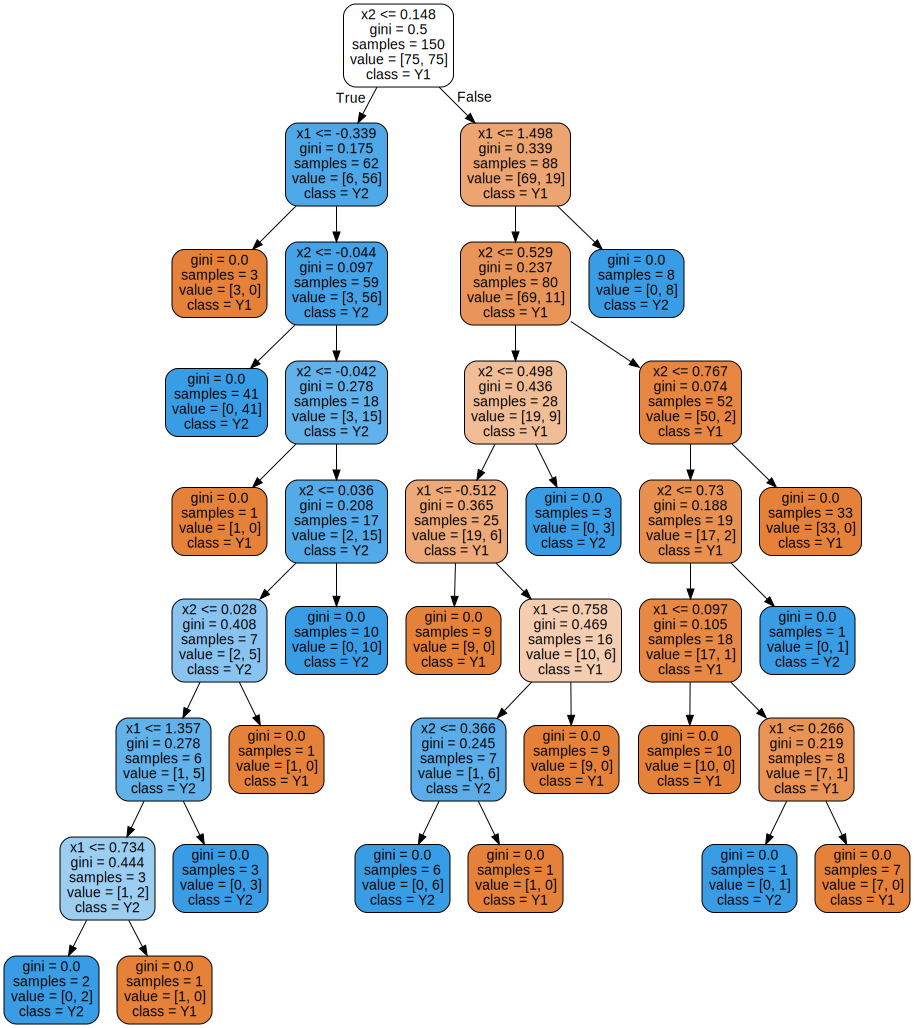

In [27]:
Source.from_file(IMAGES_PATH / "moons_tree_no_restrictions.dot")

In [23]:
!dot -Tpng {IMAGES_PATH / "moons_tree_no_restrictions.dot"} -o {IMAGES_PATH / "moons_tree_no_restrictions.png"}

**Gerando a Imagem da Árvore de decisão com Restrição de quantidade de amostras por folha**

In [24]:
export_graphviz(
        tree_clf2,
        out_file=str(IMAGES_PATH / "moons_tree_leaf_sample_restrictions.dot"),
        feature_names=["x1", "x2"],
        class_names=["Y1", "Y2"],
        rounded=True,
        filled=True
    )

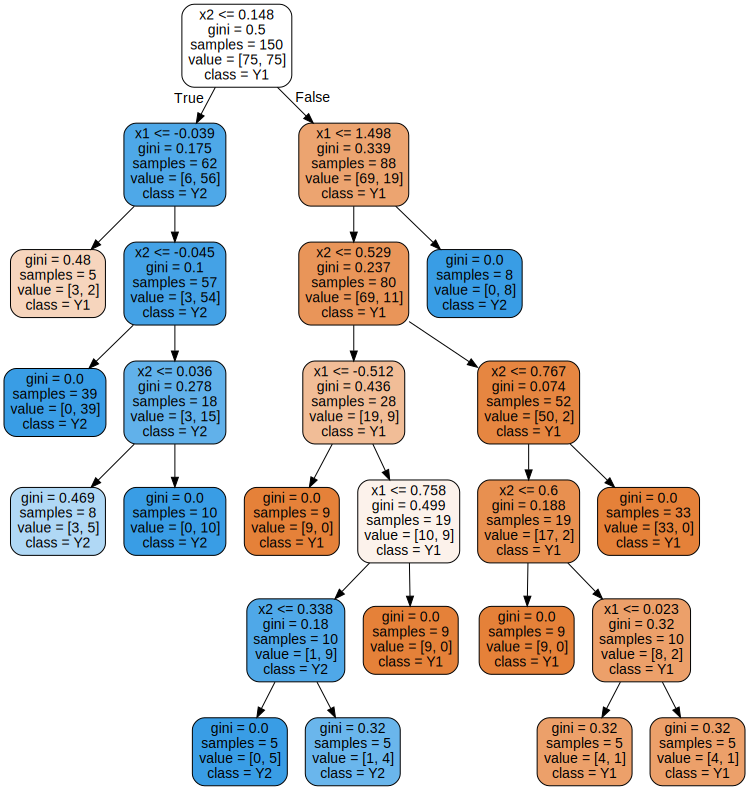

In [28]:
Source.from_file(IMAGES_PATH / "moons_tree_leaf_sample_restrictions.dot")

In [25]:
!dot -Tpng {IMAGES_PATH / "moons_tree_leaf_sample_restrictions.dot"} -o {IMAGES_PATH / "moons_tree_leaf_sample_restrictions.png"}

### FIM DA 2ª DA DEMONSTRAÇÃO - voltar aos slides

# Regressão com Árvores

**Exemplo** → Vamos preparar um Conjunto de Dados quadratico simples, e treinar uma Árvore de Decisão para este modelo, com `max_depth` com valor `2`:

In [ ]:
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
X_quad = np.random.rand(200, 1) - 0.5  # a single random input feature
y_quad = X_quad ** 2 + 0.025 * np.random.randn(200, 1)

tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_quad, y_quad)

DecisionTreeRegressor(max_depth=2, random_state=42)

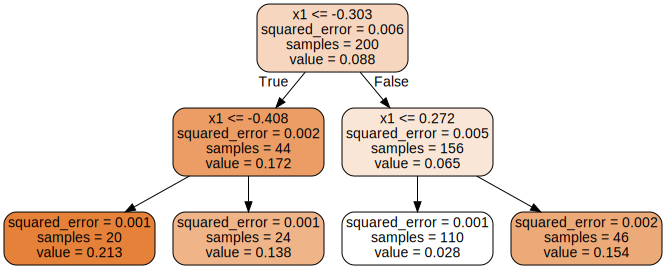

In [ ]:
export_graphviz(
    tree_reg,
    out_file=str(IMAGES_PATH / "regression_tree.dot"),
    feature_names=["x1"],
    rounded=True,
    filled=True
)
Source.from_file(IMAGES_PATH / "regression_tree.dot")

In [ ]:
!dot -Tpng {IMAGES_PATH / "regression_tree.dot"} -o {IMAGES_PATH / "regression_tree.png"}

In [ ]:
tree_reg.tree_.threshold

array([-0.30265072, -0.40830374, -2.        , -2.        ,  0.27175756,
       -2.        , -2.        ])

**2º Modelo** → Aqui treinaremos um segundo modelo de Árvore de Decisão, mas agora com `max_depth` preenchido com `3`:

In [ ]:
tree_reg2 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg2.fit(X_quad, y_quad)

DecisionTreeRegressor(max_depth=3, random_state=42)

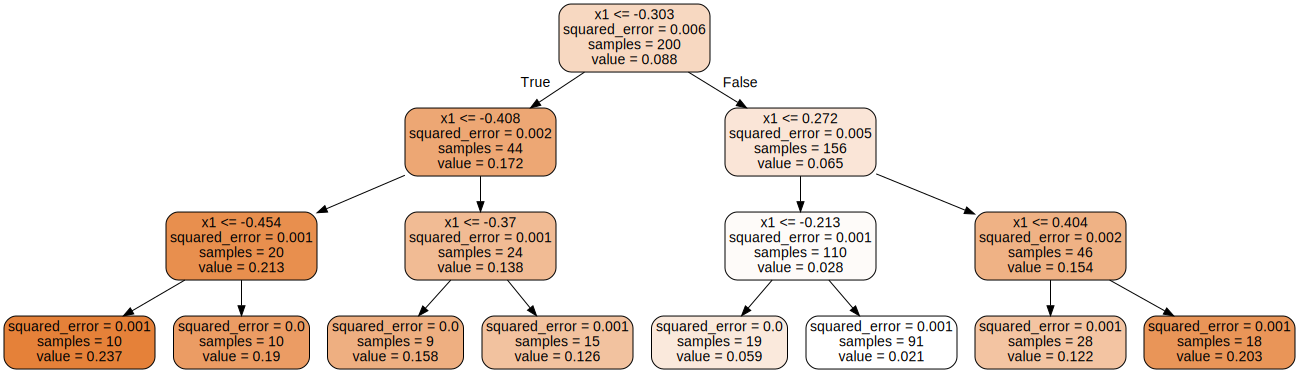

In [ ]:
export_graphviz(
    tree_reg2,
    out_file=str(IMAGES_PATH / "regression_tree2.dot"),
    feature_names=["x1"],
    rounded=True,
    filled=True
)
Source.from_file(IMAGES_PATH / "regression_tree2.dot")

In [ ]:
!dot -Tpng {IMAGES_PATH / "regression_tree2.dot"} -o {IMAGES_PATH / "regression_tree2.png"}

In [ ]:
tree_reg2.tree_.threshold

array([-0.30265072, -0.40830374, -0.45416115, -2.        , -2.        ,
       -0.37022041, -2.        , -2.        ,  0.27175756, -0.21270403,
       -2.        , -2.        ,  0.40399227, -2.        , -2.        ])

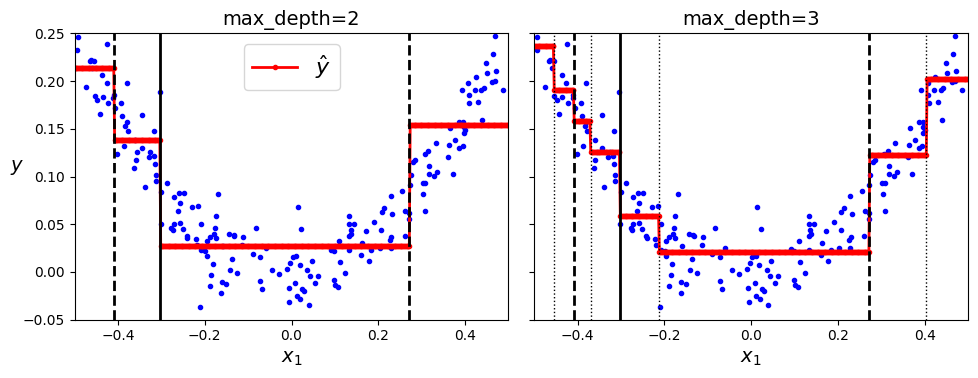

In [ ]:
def plot_regression_predictions(tree_reg, X, y, axes=[-0.5, 0.5, -0.05, 0.25]):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)
    plt.axis(axes)
    plt.xlabel("$x_1$")
    plt.plot(X, y, "b.")
    plt.plot(x1, y_pred, "r.-", linewidth=2, label=r"$\hat{y}$")

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_regression_predictions(tree_reg, X_quad, y_quad)

th0, th1a, th1b = tree_reg.tree_.threshold[[0, 1, 4]]
for split, style in ((th0, "k-"), (th1a, "k--"), (th1b, "k--")):
    plt.plot([split, split], [-0.05, 0.25], style, linewidth=2)
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center", fontsize=16)
plt.title("max_depth=2")

plt.sca(axes[1])
th2s = tree_reg2.tree_.threshold[[2, 5, 9, 12]]
plot_regression_predictions(tree_reg2, X_quad, y_quad)
for split, style in ((th0, "k-"), (th1a, "k--"), (th1b, "k--")):
    plt.plot([split, split], [-0.05, 0.25], style, linewidth=2)
for split in th2s:
    plt.plot([split, split], [-0.05, 0.25], "k:", linewidth=1)
plt.title("max_depth=3")

save_fig("tree_regression_plot")
plt.show()

**Outros Modelos** → Agora temos outros 2 modelos um sem limitações (que claramente sobreajustou), e outro com `min_samples_leaf` com valor `10`

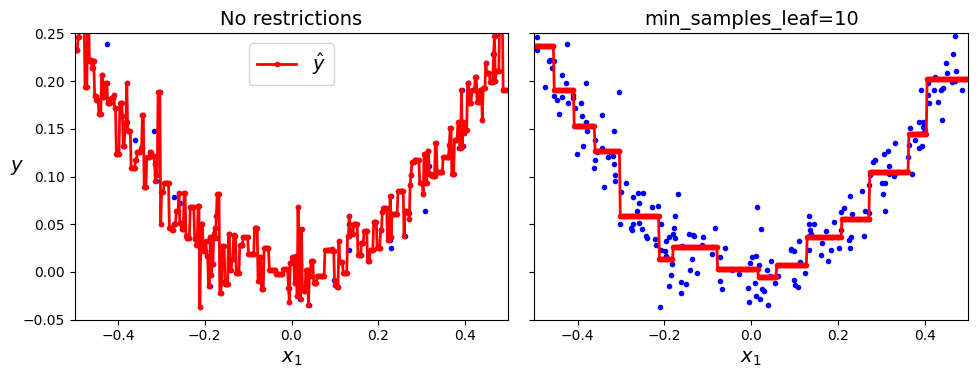

In [ ]:
tree_reg1 = DecisionTreeRegressor(random_state=42)
tree_reg2 = DecisionTreeRegressor(random_state=42, min_samples_leaf=10)
tree_reg1.fit(X_quad, y_quad)
tree_reg2.fit(X_quad, y_quad)

x1 = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)
y_pred1 = tree_reg1.predict(x1)
y_pred2 = tree_reg2.predict(x1)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

plt.sca(axes[0])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred1, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center")
plt.title("No restrictions")

plt.sca(axes[1])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred2, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.title(f"min_samples_leaf={tree_reg2.min_samples_leaf}")

save_fig("tree_regression_regularization_plot")
plt.show()

### FIM DA 3ª DA DEMONSTRAÇÃO - voltar aos slides

# Vantagens e Limitações

## Sensibilidade à Orientação do Eixo

Rotacionar os dados, leva a fronteiras de decisão completamente diferentes:

*Aqui será criado um pequeno dataset, com 2 propriedades (X1 e X2). Sempre que X1 for positivo, o `Y` será `true` e quando negativo, o `Y` será `false`*

Observe o que acontece com a fronteira de decisão quando os dados são rotacionados.

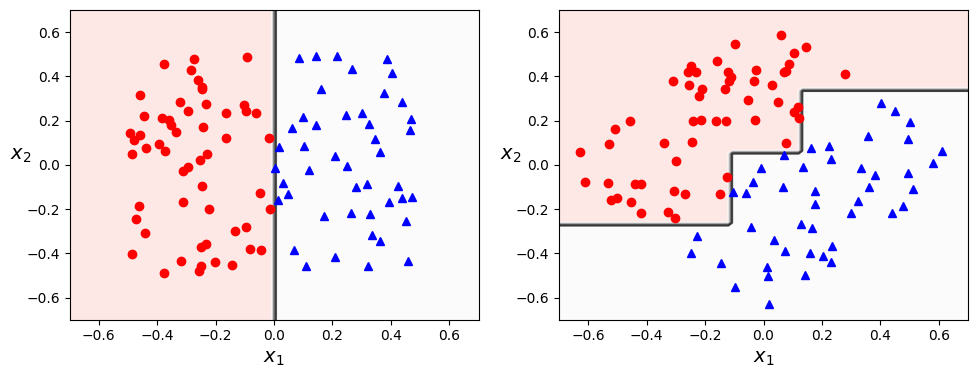

In [ ]:
np.random.seed(6)
X_square = np.random.rand(100, 2) - 0.5
y_square = (X_square[:, 0] > 0).astype(np.int64)

angle = np.pi / 4  # 45 degrees
rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)],
                            [np.sin(angle), np.cos(angle)]])
X_rotated_square = X_square.dot(rotation_matrix)

tree_clf_square = DecisionTreeClassifier(random_state=42)
tree_clf_square.fit(X_square, y_square)
tree_clf_rotated_square = DecisionTreeClassifier(random_state=42)
tree_clf_rotated_square.fit(X_rotated_square, y_square)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4))
plt.sca(axes[0])
plot_decision_boundary(tree_clf_square, X_square, y_square,
                       axes=[-0.7, 0.7, -0.7, 0.7], cmap="Pastel1")


plt.sca(axes[1])
plot_decision_boundary(tree_clf_rotated_square, X_rotated_square, y_square,
                       axes=[-0.7, 0.7, -0.7, 0.7], cmap="Pastel1")
#plt.ylabel("")

save_fig("sensitivity_to_rotation_plot")
plt.show()

### Agora temos um pequeno exemplo utilizando o Dataset Iris

- Neste exemplo, será aplicado uma transformação de PCA(Análise de Componentes Principais) para ajustar a escala dos dados, e assim, simplificar a Árvore de Decisão!

In [ ]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pca_pipeline = make_pipeline(StandardScaler(), PCA())
X_iris_rotated = pca_pipeline.fit_transform(X_iris)
tree_clf_pca = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf_pca.fit(X_iris_rotated, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

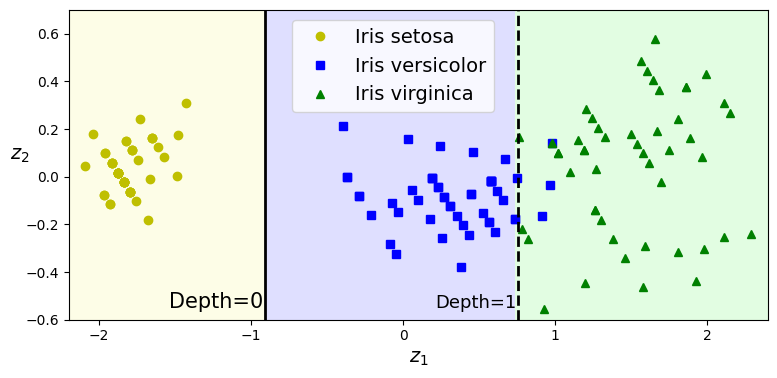

In [ ]:
plt.figure(figsize=(8, 4))

axes = [-2.2, 2.4, -0.6, 0.7]
z0s, z1s = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                       np.linspace(axes[2], axes[3], 100))
X_iris_pca_all = np.c_[z0s.ravel(), z1s.ravel()]
y_pred = tree_clf_pca.predict(X_iris_pca_all).reshape(z0s.shape)

plt.contourf(z0s, z1s, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris_rotated[:, 0][y_iris == idx],
             X_iris_rotated[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

plt.xlabel("$z_1$")
plt.ylabel("$z_2$", rotation=0)
th1, th2 = tree_clf_pca.tree_.threshold[[0, 2]]
plt.plot([th1, th1], axes[2:], "k-", linewidth=2)
plt.plot([th2, th2], axes[2:], "k--", linewidth=2)
plt.text(th1 - 0.01, axes[2] + 0.05, "Depth=0",
         horizontalalignment="right", fontsize=15)
plt.text(th2 - 0.01, axes[2] + 0.05, "Depth=1",
         horizontalalignment="right", fontsize=13)
plt.axis(axes)
plt.legend(loc=(0.32, 0.67))
save_fig("pca_preprocessing_plot")

plt.show()

## Árvores de Decisão tem Alta Variância

Vimos que pequenas mudanças no conjunto de dados (como uma rotação) podem produzir uma Árvore de Decisão muito diferente.

Agora vamos mostrar que treinar o mesmo modelo com os mesmos dados pode gerar um modelo muito diferente a cada execução, já que o algoritmo de treinamento CART utilizado pelo Scikit-Learn é estocástico. Para demonstrar isso, vamos definir `random_state` com um valor diferente do anterior:

In [ ]:
tree_clf_tweaked = DecisionTreeClassifier(max_depth=2, random_state=40)
tree_clf_tweaked.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=40)

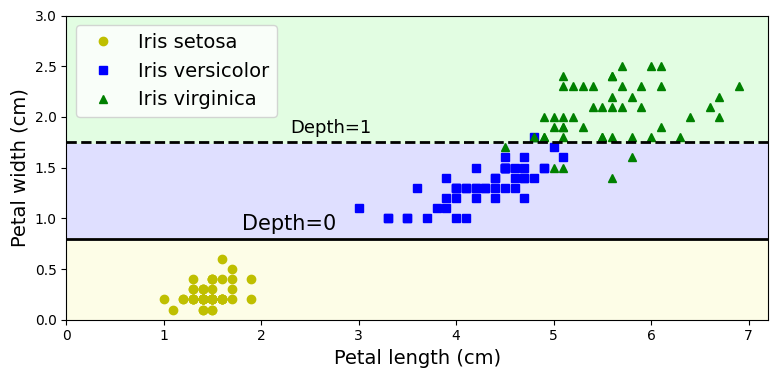

In [ ]:
plt.figure(figsize=(8, 4))
y_pred = tree_clf_tweaked.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)

for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

th0, th1 = tree_clf_tweaked.tree_.threshold[[0, 2]]
plt.plot([0, 7.2], [th0, th0], "k-", linewidth=2)
plt.plot([0, 7.2], [th1, th1], "k--", linewidth=2)
plt.text(1.8, th0 + 0.05, "Depth=0", verticalalignment="bottom", fontsize=15)
plt.text(2.3, th1 + 0.05, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.axis([0, 7.2, 0, 3])
plt.legend()
save_fig("decision_tree_high_variance_plot")

plt.show()

### FIM DA 4ª DA DEMONSTRAÇÃO - voltar aos slides

# Exercícios

Este exercício deve ser desenvolvido utilizando o conjunto de dados que você pode carregar utilizando a função `sklearn.datasets.loadwine()`, conforme exemplo abaixo.

Este Dataset contém 174 amostras de vinho de 3 produtores diferentes

1. Prepare um novo modelo de classificação utilizando o Dataset Wine, com o objetivo de identificar o Produtor do Vinho, utilizando todas as características que julgar necessárias.

Calcule previsões, utilizando informações do Conjunto de Validação do Modelo.

In [ ]:
# RESOLUÇÃO EXERCÍCIO 1

2. Avalie o seu modelo, verificando se ele não está sobreajustado utilizando o Conjunto de Validação.
Faça testes realizando ajustes no seu modelo aplicando restrições ao seu modelo.

In [ ]:
# RESOLUÇÃO EXERCÍCIO 2

3. Utilizando o Modelo que você desenvolveu, calcule as informações de Acurácia, Precisão, Recall e F1 Score para o modelo desenvolvido.

Considerando as métricas identificadas, e tudo o que já aprendeu, reveja o seu modelo, procurando identificar em todo o processo pontos que podem ter comprometido seu modelo de alguma forma.

Avalie se é possível melhorar o seu desempenho ajustando parâmetros ou melhorando o pré-processamento e ajuste o modelo.

Procure realizar ajustes no seu modelo com o objetivo de obter o melhor resultado possível para a métrica F1 Score.

In [ ]:
# RESOLUÇÃO EXERCÍCIO 3

4. De forma semelhante ao que já realizamos nas aulas anteriores envolvendo modelos de Regressão, gere um novo conjunto de dados com `500` amostras e `0.7` de ruído.
Treine uma árvore de Decisão para estes dados.

In [ ]:
# RESOLUÇÃO EXERCÍCIO 4

5. Calcule o RMSE para o modelo calculado. Avalie a possibilidade de sobreajuste no modelo. Realize os ajustes necessários para evitar que o Modelo fique com Sobreajuste(Overfitting).

In [ ]:
# RESOLUÇÃO EXERCÍCIO 5